# 05 - Transfer Learning (MobileNetV2)

1. **original** - `data/split`
2. **CLAHE** - `data/enhanced/clahe`
3. **CLAHE + Gaussian** - `data/enhanced/clahe_gaussian`
4. **GRABCUT + Original** - `data/segmented_grabcut`

In [5]:
# ini yang pakai cpu
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

## 1. Import dan Konfigurasi

In [6]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

NUM_THREADS = min(8, os.cpu_count() or 4)
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError as exc:
    print("Device TensorFlow sudah aktif, konfigurasi :", exc)

try:
    tf.config.threading.set_intra_op_parallelism_threads(NUM_THREADS)
    tf.config.threading.set_inter_op_parallelism_threads(NUM_THREADS)
except RuntimeError as exc:
    print("Threading TensorFlow sudah aktif, konfigurasi :", exc)

IMG_SIZE = (192, 192)
BATCH_SIZE = 10
SEED = 42

EPOCHS_HEAD = 10
DO_FINETUNE = True
EPOCHS_FINETUNE = 5
UNFREEZE_LAST_N = 10

LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

keras.utils.set_random_seed(SEED)

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

elif (CURRENT_DIR / "data" / "split").exists():
    PROJECT_ROOT = CURRENT_DIR

else:
    PROJECT_ROOT = Path("..").resolve()


DIR_ORIGINAL = PROJECT_ROOT / "data" / "split"

DIR_CLAHE = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe"
)

DIR_CLAHE_GAUSSIAN = (
    PROJECT_ROOT
    / "data"
    / "enhanced"
    / "clahe_gaussian"
)

DIR_GRABCUT_ORIGINAL = (
    PROJECT_ROOT
    / "data"
    / "segmented_grabcut"
)

DIR_MODELS = PROJECT_ROOT / "models"
DIR_METRICS = PROJECT_ROOT / "results" / "metrics"
DIR_FIGURES = PROJECT_ROOT / "results" / "figures"

for d in (DIR_MODELS, DIR_METRICS, DIR_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = ["biological", "cardboard", "glass", "metal", "paper", "plastic"]
NUM_CLASSES = len(EXPECTED_CLASSES)

print("TensorFlow:", tf.__version__)
print("Physical GPU:", tf.config.list_physical_devices("GPU"))
print("Logical GPU :", tf.config.list_logical_devices("GPU"))
print("Device mode : CPU")
print("CPU threads :", NUM_THREADS)
print("Project root:", PROJECT_ROOT)
print("IMG_SIZE   :", IMG_SIZE)
print("BATCH_SIZE :", BATCH_SIZE)
print("Original Dataset :", DIR_ORIGINAL, "->", DIR_ORIGINAL.exists())
print("CLAHE Dataset    :", DIR_CLAHE, "->", DIR_CLAHE.exists())
print("CLAHE+Gaussian   :", DIR_CLAHE_GAUSSIAN, "->", DIR_CLAHE_GAUSSIAN.exists())
print("GRABCUT+Original   :", DIR_GRABCUT_ORIGINAL, "->", DIR_GRABCUT_ORIGINAL.exists())

TensorFlow: 2.21.0
Physical GPU: []
Logical GPU : []
Device mode : CPU
CPU threads : 8
Project root: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn
IMG_SIZE   : (192, 192)
BATCH_SIZE : 10
Original Dataset : D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\split -> True
CLAHE Dataset    : D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe -> True
CLAHE+Gaussian   : D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\enhanced\clahe_gaussian -> True
GRABCUT+Original   : D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\data\segmented_grabcut -> True


## 2. Helper Evaluasi

In [7]:
def compute_metrics(y_true, y_pred):
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "precision_macro": round(float(p_macro), 4),
        "recall_macro": round(float(r_macro), 4),
        "f1_macro": round(float(f_macro), 4),
    }


def plot_confusion(y_true, y_pred, class_names, title, file_name):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Prediksi")
    plt.ylabel("Label Asli")
    plt.tight_layout()
    path = DIR_FIGURES / file_name
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)
    return cm


def eval_on_test(model, ds_test):
    y_true, y_pred = [], []
    for xb, yb in ds_test:
        probs = model.predict(xb, verbose=0)
        pred = probs.argmax(axis=1)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.tolist())
    return np.array(y_true), np.array(y_pred)

## 3. Pipeline Data

In [8]:
def make_datasets(base_dir):
    def load(split, shuffle):
        return keras.utils.image_dataset_from_directory(
            base_dir / split,
            labels="inferred",
            label_mode="int",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            seed=SEED,
        )

    ds_train = load("train", True)
    ds_val = load("val", False)
    ds_test = load("test", False)

    class_names = ds_train.class_names
    assert class_names == EXPECTED_CLASSES, f"Urutan kelas tidak sesuai: {class_names}"

    options = tf.data.Options()
    options.threading.private_threadpool_size = NUM_THREADS
    options.threading.max_intra_op_parallelism = 1

    ds_train = ds_train.with_options(options).prefetch(1)
    ds_val = ds_val.with_options(options).prefetch(1)
    ds_test = ds_test.with_options(options).prefetch(1)
    return ds_train, ds_val, ds_test, class_names


# ORIGINAL
ds_train_original, ds_val_original, ds_test_original, CLASS_NAMES = \
    make_datasets(DIR_ORIGINAL)

# CLAHE
ds_train_clahe, ds_val_clahe, ds_test_clahe, _ = \
    make_datasets(DIR_CLAHE)

# CLAHE + GAUSSIAN
ds_train_clahe_gaussian, ds_val_clahe_gaussian, ds_test_clahe_gaussian, _ = \
    make_datasets(DIR_CLAHE_GAUSSIAN)

# ORIGINAL + GRABCUT
ds_train_grabcut_original, ds_val_grabcut_original, ds_test_grabcut_original, _ = \
    make_datasets(DIR_GRABCUT_ORIGINAL)

print("Kelas:", CLASS_NAMES)


# Data Augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.05, seed=SEED),
    ],
    name="data_augmentation",
)

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Kelas: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


In [9]:
# cek apakah ada folder kosong atau jumlah data yg beda
print("\n=== ORIGINAL ===")
print("Train batches:", tf.data.experimental.cardinality(ds_train_original).numpy())
print("Val batches  :", tf.data.experimental.cardinality(ds_val_original).numpy())
print("Test batches :", tf.data.experimental.cardinality(ds_test_original).numpy())

print("\n=== CLAHE ===")
print("Train batches:", tf.data.experimental.cardinality(ds_train_clahe).numpy())
print("Val batches  :", tf.data.experimental.cardinality(ds_val_clahe).numpy())
print("Test batches :", tf.data.experimental.cardinality(ds_test_clahe).numpy())

print("\n=== CLAHE + GAUSSIAN ===")
print("Train batches:", tf.data.experimental.cardinality(ds_train_clahe_gaussian).numpy())
print("Val batches  :", tf.data.experimental.cardinality(ds_val_clahe_gaussian).numpy())
print("Test batches :", tf.data.experimental.cardinality(ds_test_clahe_gaussian).numpy())

print("\n=== ORIGINAL + GRABCUT ===")
print("Train batches:", tf.data.experimental.cardinality(ds_train_grabcut_original).numpy())
print("Val batches  :", tf.data.experimental.cardinality(ds_val_grabcut_original).numpy())
print("Test batches :", tf.data.experimental.cardinality(ds_test_grabcut_original).numpy())


=== ORIGINAL ===
Train batches: 540
Val batches  : 116
Test batches : 116

=== CLAHE ===
Train batches: 540
Val batches  : 116
Test batches : 116

=== CLAHE + GAUSSIAN ===
Train batches: 540
Val batches  : 116
Test batches : 116

=== ORIGINAL + GRABCUT ===
Train batches: 540
Val batches  : 116
Test batches : 116


## 4. Model Transfer Learning

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def build_transfer_model():
    keras.utils.set_random_seed(SEED)
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
    )
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)  # Disini ada proses normalisasi yang sesuai dengan MobileNetV2, dari 0-255 ke -1 sampai 1
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_CPU")
    model.compile(
        optimizer=keras.optimizers.Adam(LR_HEAD),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model, base


model, base_model = build_transfer_model()
model.summary()

Model: "MobileNetV2_CPU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Training

In [13]:
HEAD_PATH = DIR_MODELS / "mobilenetv2_head_best.keras"
FINETUNE_PATH = DIR_MODELS / "mobilenetv2_finetune_best.keras"
BEST_PATH = DIR_MODELS / "mobilenetv2_best.keras"


def make_callbacks(path_model, patience=3):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(path_model),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]


def plot_history(histories, title, file_name):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in histories:
        acc.extend(hist.history["accuracy"])
        val_acc.extend(hist.history["val_accuracy"])
        loss.extend(hist.history["loss"])
        val_loss.extend(hist.history["val_loss"])

    epochs = range(1, len(acc) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(epochs, acc, label="train")
    ax[0].plot(epochs, val_acc, label="val")
    ax[0].set_title(f"{title} - Accuracy")
    ax[0].set_xlabel("epoch")
    ax[0].legend()

    ax[1].plot(epochs, loss, label="train")
    ax[1].plot(epochs, val_loss, label="val")
    ax[1].set_title(f"{title} - Loss")
    ax[1].set_xlabel("epoch")
    ax[1].legend()

    if len(histories) > 1:
        boundary = len(histories[0].history["accuracy"]) + 0.5
        for item in ax:
            item.axvline(boundary, color="gray", ls="--", alpha=0.7)

    plt.tight_layout()
    path = DIR_FIGURES / file_name
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)

### Fungsi untuk ngejalanin eksperimen

In [11]:
def run_experiment(
    scenario_name,
    ds_train,
    ds_val,
    ds_test,
):
    
    print(f"\n{'='*50}")
    print(f"SCENARIO: {scenario_name}")
    print(f"{'='*50}")

    rows = []
    histories = []

    model, base_model = build_transfer_model()

    head_path = DIR_MODELS / f"{scenario_name}_head.keras"
    finetune_path = DIR_MODELS / f"{scenario_name}_finetune.keras"

    # HEAD TRAINING
    history_head = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_HEAD,
        callbacks=make_callbacks(head_path, patience=3),
        verbose=1,
    )

    histories.append(history_head)

    model_head = (
        keras.models.load_model(head_path)
        if head_path.exists()
        else model
    )

    y_head, pred_head = eval_on_test(
        model_head,
        ds_test,
    )

    m_head = compute_metrics(
        y_head,
        pred_head,
    )

    m_head.update({
        "model": "MobileNetV2",
        "scenario": scenario_name,
        "phase": "head",
    })

    rows.append(m_head)

    # FINETUNE
    if DO_FINETUNE and EPOCHS_FINETUNE > 0:

        model = (
            keras.models.load_model(head_path)
            if head_path.exists()
            else model
        )

        base = next(
            layer
            for layer in model.layers
            if layer.name.startswith("mobilenetv2")
        )

        base.trainable = True

        for layer in base.layers[:-UNFREEZE_LAST_N]:
            layer.trainable = False

        for layer in base.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(LR_FINETUNE),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )

        history_ft = model.fit(
            ds_train,
            validation_data=ds_val,
            epochs=EPOCHS_FINETUNE,
            callbacks=make_callbacks(
                finetune_path,
                patience=2,
            ),
            verbose=1,
        )

        histories.append(history_ft)

        model_ft = (
            keras.models.load_model(finetune_path)
            if finetune_path.exists()
            else model
        )

        y_ft, pred_ft = eval_on_test(
            model_ft,
            ds_test,
        )

        m_ft = compute_metrics(
            y_ft,
            pred_ft,
        )

        m_ft.update({
            "model": "MobileNetV2",
            "scenario": scenario_name,
            "phase": "finetune",
        })

        rows.append(m_ft)

    plot_history(
        histories,
        f"MobileNetV2 - {scenario_name}",
        f"history_{scenario_name}.png",
    )

    return pd.DataFrame(rows)

### Lakukan Training untuk Ketiga Skenario Eksperimen


SCENARIO: original
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 88s 156ms/step - accuracy: 0.7715 - loss: 0.6399 - val_accuracy: 0.8304 - val_loss: 0.4520 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 99s 183ms/step - accuracy: 0.8608 - loss: 0.3889 - val_accuracy: 0.8512 - val_loss: 0.3906 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 105s 194ms/step - accuracy: 0.8827 - loss: 0.3142 - val_accuracy: 0.8720 - val_loss: 0.3359 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8991 - loss: 0.2607
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━━━━━━━ 98s 181ms/step - accuracy: 0.9057 - loss: 0.2499 - val_accuracy: 0.8668 - val_loss: 0.3735 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 109s 201ms/step - accuracy: 0.9316 - loss: 0.1847 - val_accuracy: 0.8841 - val_loss: 0.3173 - learning_rate: 5.0000e-04
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 116s 2

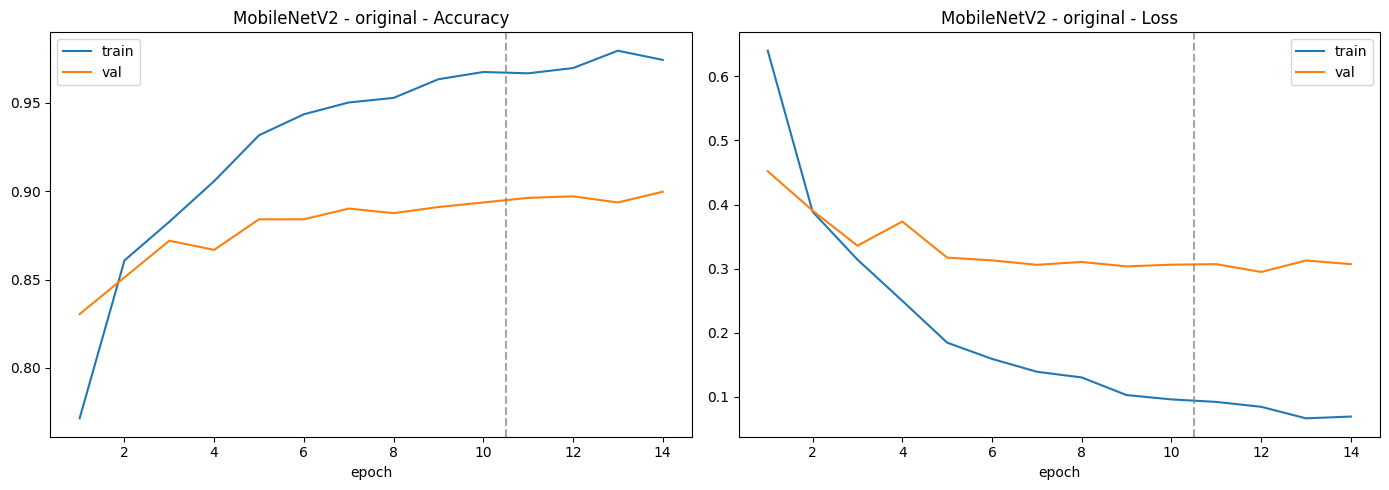

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\history_original.png


In [15]:
# Eksperimen 1: ORIGINAL
results_original = run_experiment(
    "original",
    ds_train_original,
    ds_val_original,
    ds_test_original,
)


SCENARIO: clahe
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 222s 404ms/step - accuracy: 0.7595 - loss: 0.6689 - val_accuracy: 0.8062 - val_loss: 0.5130 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 102s 189ms/step - accuracy: 0.8540 - loss: 0.4103 - val_accuracy: 0.8538 - val_loss: 0.4001 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 205s 380ms/step - accuracy: 0.8788 - loss: 0.3322 - val_accuracy: 0.8564 - val_loss: 0.3807 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8926 - loss: 0.2965
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━━━━━━━ 206s 381ms/step - accuracy: 0.8940 - loss: 0.2894 - val_accuracy: 0.8616 - val_loss: 0.4156 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 84s 155ms/step - accuracy: 0.9244 - loss: 0.2068 - val_accuracy: 0.8685 - val_loss: 0.3679 - learning_rate: 5.0000e-04
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 147m

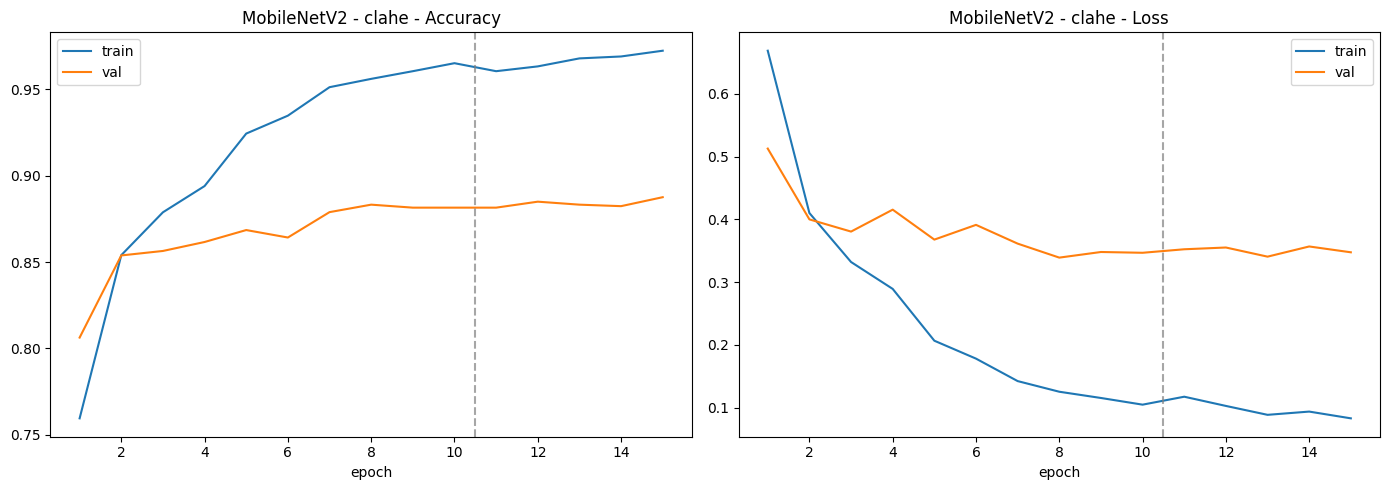

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\history_clahe.png


In [16]:
# Eksperimen 2: CLAHE
results_clahe = run_experiment(
    "clahe",
    ds_train_clahe,
    ds_val_clahe,
    ds_test_clahe,
)


SCENARIO: clahe_gaussian
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 83s 148ms/step - accuracy: 0.7637 - loss: 0.6709 - val_accuracy: 0.8209 - val_loss: 0.4765 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 64s 118ms/step - accuracy: 0.8477 - loss: 0.4213 - val_accuracy: 0.8486 - val_loss: 0.4008 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 124s 230ms/step - accuracy: 0.8779 - loss: 0.3330 - val_accuracy: 0.8702 - val_loss: 0.3783 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9013 - loss: 0.2788
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━━━━━━━ 66s 122ms/step - accuracy: 0.9010 - loss: 0.2779 - val_accuracy: 0.8564 - val_loss: 0.4098 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 64s 119ms/step - accuracy: 0.9272 - loss: 0.2038 - val_accuracy: 0.8824 - val_loss: 0.3398 - learning_rate: 5.0000e-04
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0

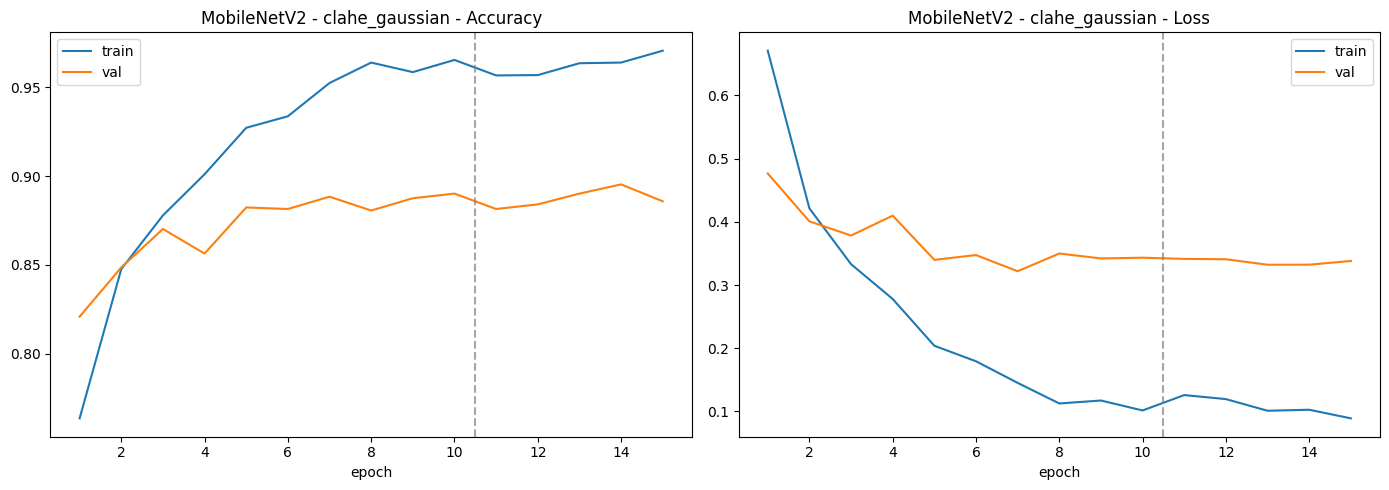

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\history_clahe_gaussian.png


In [17]:
# Eksperimen 3: CLAHE + GAUSSIAN
results_clahe_gaussian = run_experiment(
    "clahe_gaussian",
    ds_train_clahe_gaussian,
    ds_val_clahe_gaussian,
    ds_test_clahe_gaussian,
)


SCENARIO: grabcut_original
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - accuracy: 0.6446 - loss: 0.9419 - val_accuracy: 0.7483 - val_loss: 0.6703 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7158 - loss: 0.7380
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.7294 - loss: 0.7076 - val_accuracy: 0.7059 - val_loss: 0.7703 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.7745 - loss: 0.5902 - val_accuracy: 0.7768 - val_loss: 0.6003 - learning_rate: 5.0000e-04
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7786 - loss: 0.5812
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
540/540 ━━━━━━━━━━━━━━━━━━━━ 51s 95ms/step - accuracy: 0.7917 - loss: 0.5493 - val_accuracy: 0.7630 - val_loss: 0.6377 - learning_rate: 5.0000e-04
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 80s

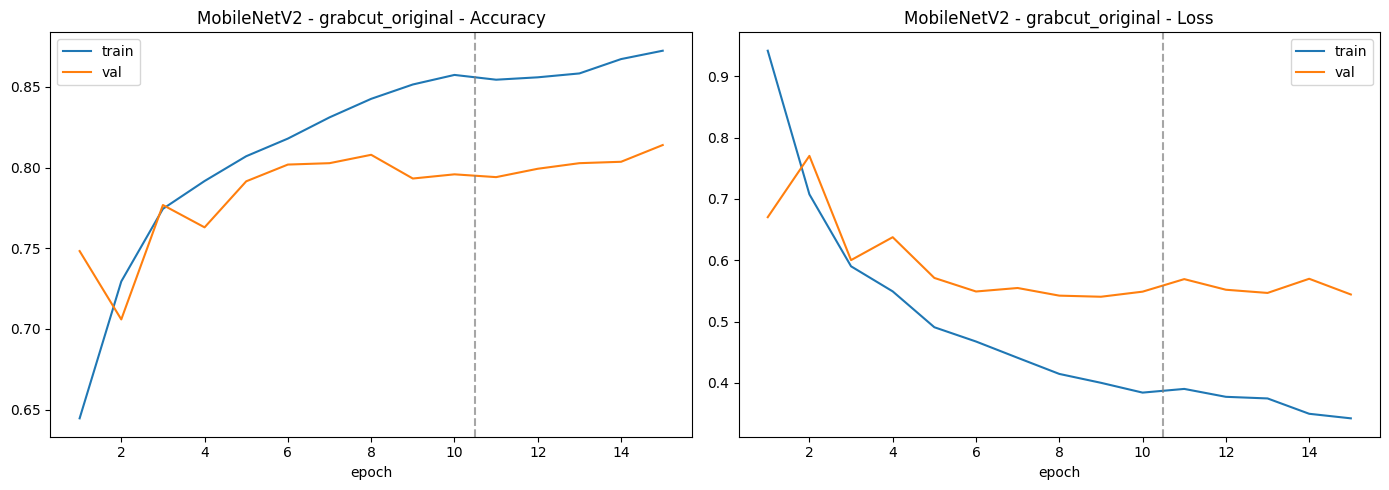

Disimpan: D:\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\PCD\waste-classification-cnn\results\figures\history_grabcut_original.png


In [ ]:
# Eksperimen 4: ORIGINAL + GRABCUT
results_grabcut_original = run_experiment(
    "grabcut_original",
    ds_train_grabcut_original,
    ds_val_grabcut_original,
    ds_test_grabcut_original,
)

In [18]:
results_all = pd.concat(
    [
        results_original,
        results_clahe,
        results_clahe_gaussian,
        results_grabcut_original
    ],
    ignore_index=True,
)

display(results_all)

,accuracy,precision_macro,recall_macro,f1_macro,model,scenario,phase
0,0.8833,0.8889,0.8948,0.8907,MobileNetV2,original,head
1,0.8894,0.8956,0.8957,0.8955,MobileNetV2,original,finetune
2,0.8721,0.8796,0.8802,0.8792,MobileNetV2,clahe,head
3,0.8790,0.8872,0.8876,0.8865,MobileNetV2,clahe,finetune
4,0.8712,0.8790,0.8782,0.8779,MobileNetV2,clahe_gaussian,head
5,0.8755,0.8815,0.8828,0.8818,MobileNetV2,clahe_gaussian,finetune
6,0.7960,0.7960,0.8069,0.7963,MobileNetV2,grabcut_original,head
7,0.8021,0.7957,0.8120,0.7994,MobileNetV2,grabcut_original,finetune


In [19]:
results_all.to_csv(
    DIR_METRICS / "cnn_mobilenetv2_results.csv",
    index=False,
)

## 6. Evaluasi dan Simpan Hasil

In [20]:
# load model terbaik tiap skenario untuk plot confusion matrix
model_original = keras.models.load_model(
    DIR_MODELS / "original_finetune.keras"
)

model_clahe = keras.models.load_model(
    DIR_MODELS / "clahe_finetune.keras"
)

model_clahe_gaussian = keras.models.load_model(
    DIR_MODELS / "clahe_gaussian_finetune.keras"
)

model_grabcut_original = keras.models.load_model(
    DIR_MODELS / "grabcut_original_finetune.keras"
)

In [21]:
# generate y_true dan y_pred untuk masing-masing model dan dataset testnya
y_true_ori, y_pred_ori = eval_on_test(
    model_original,
    ds_test_original
)

y_true_clahe, y_pred_clahe = eval_on_test(
    model_clahe,
    ds_test_clahe
)

y_true_cg, y_pred_cg = eval_on_test(
    model_clahe_gaussian,
    ds_test_clahe_gaussian
)

y_true_go, y_pred_go = eval_on_test(
    model_grabcut_original,
    ds_test_grabcut_original
)

In [24]:
# plot perbandingan confusion matrix
from sklearn.metrics import confusion_matrix

def plot_confusion_comparison(
    y_true_ori,
    y_pred_ori,
    y_true_clahe,
    y_pred_clahe,
    y_true_cg,
    y_pred_cg,
    y_true_go,
    y_pred_go,
    class_names,
):

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(22,6)
    )

    scenarios = [
        (y_true_ori, y_pred_ori, "Original"),
        (y_true_clahe, y_pred_clahe, "CLAHE"),
        (y_true_cg, y_pred_cg, "CLAHE + Gaussian"),
        (y_true_go, y_pred_go, "Original + GRABCUT"),
    ]

    for ax, (yt, yp, title) in zip(
        axes,
        scenarios
    ):

        cm = confusion_matrix(
            yt,
            yp,
            labels=range(len(class_names))
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax,
        )

        ax.set_title(title)
        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Label Asli")

    plt.tight_layout()
    plt.show()

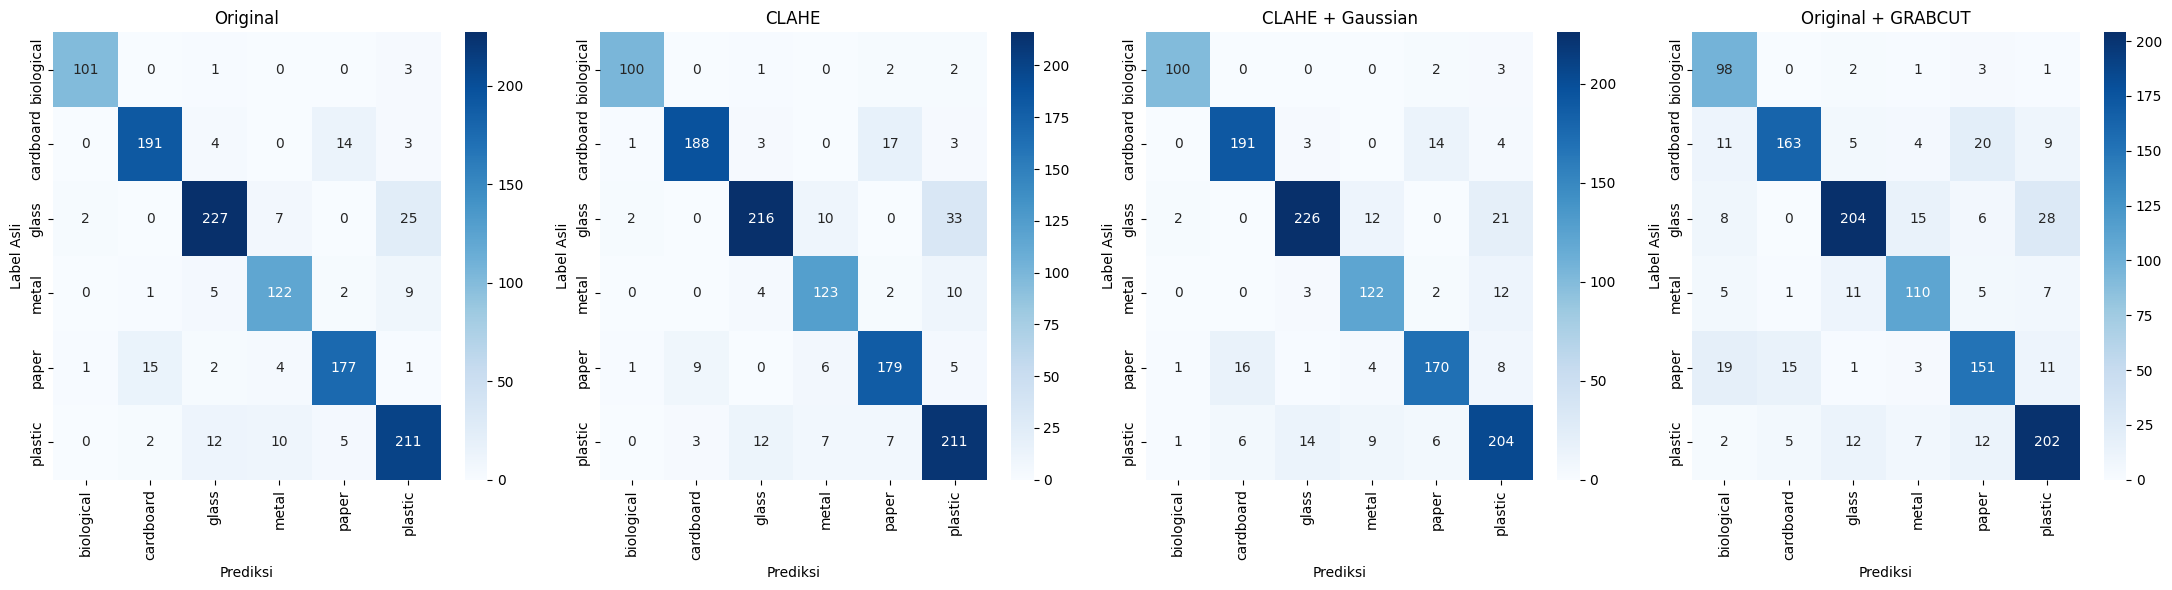

In [25]:
plot_confusion_comparison(
    y_true_ori,
    y_pred_ori,
    y_true_clahe,
    y_pred_clahe,
    y_true_cg,
    y_pred_cg,
    y_true_go,
    y_pred_go,
    CLASS_NAMES
)